# 07 · Demographic Analysis

Analyses LSOA-level sociodemographic features (age, occupation, tenure)
in relation to planning comment density.

**Prerequisite:** Run  first.


In [1]:
import sys
sys.path.append("../functions")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.stats import ttest_ind, pearsonr

from config import RESULTS_DIR, FIGURES_DIR
from data_loader import load_census, load_lsoa_boundaries

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

comment_df = pd.read_parquet(RESULTS_DIR / "comments.parquet")


## Load census and boundaries

In [2]:
df_census = load_census()
lsoa_cols = df_census["LSOA code"].tolist()
lsoa_gdf  = load_lsoa_boundaries(lsoa_codes=lsoa_cols)
print(f"Census LSOAs: {len(df_census):,}  |  Boundary LSOAs: {len(lsoa_gdf):,}")


Census LSOAs: 4,994  |  Boundary LSOAs: 4,994


## Assign LSOA to each comment via spatial join

In [3]:
# Convert comment coordinates to GeoDataFrame
cs_gdf = gpd.GeoDataFrame(
    comment_df,
    geometry=gpd.points_from_xy(comment_df["lon"], comment_df["lat"]),
    crs="EPSG:4326",
).to_crs(lsoa_gdf.crs)

joined = gpd.sjoin(cs_gdf, lsoa_gdf[["LSOA21CD", "geometry"]], how="left", predicate="within")
comment_df["lsoa_code"] = joined["LSOA21CD"].values

print(f"Matched {comment_df['lsoa_code'].notna().sum():,} / {len(comment_df):,} comments to an LSOA")


Matched 23,645 / 30,393 comments to an LSOA


## Merge census features into comments

In [4]:
socio_vars = ["percent_age_50_plus", "percent_occupation_1_2_3", "percent_owned_total"]

comment_df = pd.merge(
    comment_df,
    df_census[["LSOA code"] + socio_vars],
    left_on="lsoa_code", right_on="LSOA code",
    how="left",
).drop(columns=["LSOA code"])


## Statistical comparison: LSOAs with vs without comments

In [5]:
lsoa_with_comments = comment_df["lsoa_code"].dropna().unique()

print("t-test: LSOAs with comments vs all London LSOAs")
for var in socio_vars:
    t_stat, p_val = ttest_ind(
        df_census[var].dropna(),
        df_census[df_census["LSOA code"].isin(lsoa_with_comments)][var].dropna(),
        equal_var=False,
    )
    print(f"  {var:35s}  t={t_stat:+.3f}  p={p_val:.4f}")


t-test: LSOAs with comments vs all London LSOAs
  percent_age_50_plus                  t=-1.581  p=0.1141
  percent_occupation_1_2_3             t=+2.369  p=0.0180
  percent_owned_total                  t=+0.914  p=0.3609


## Scatter plots: comments per LSOA vs sociodemographic variables

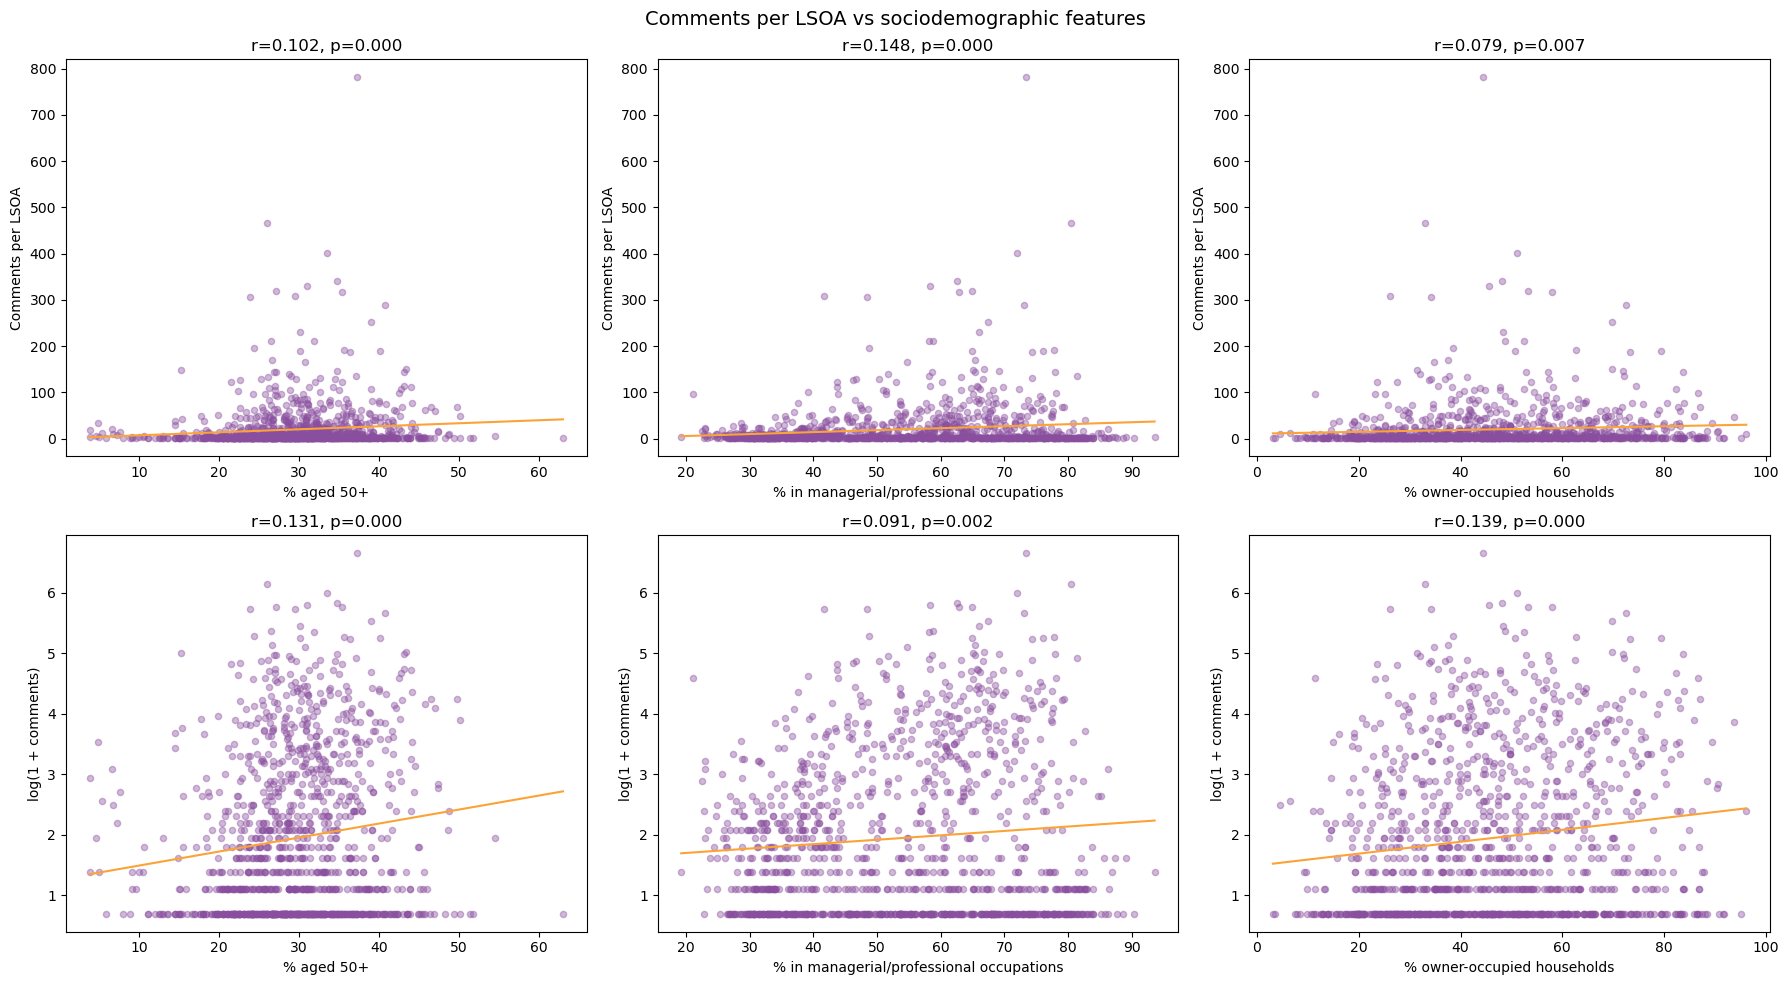

In [6]:
grouped = (
    comment_df
    .groupby("lsoa_code")
    .agg(num_comments=("comment_id", "count"), **{v: (v, "mean") for v in socio_vars})
    .reset_index()
)

x_labels = {
    "percent_age_50_plus":       "% aged 50+",
    "percent_occupation_1_2_3":  "% in managerial/professional occupations",
    "percent_owned_total":       "% owner-occupied households",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, (ax_raw, ax_log) in zip(socio_vars, zip(axes[0], axes[1])):
    x = grouped[col]
    y_raw = grouped["num_comments"]
    y_log = np.log1p(y_raw)

    for ax, y, ylabel in [(ax_raw, y_raw, "Comments per LSOA"),
                           (ax_log, y_log, "log(1 + comments)")]:
        ax.scatter(x, y, alpha=0.4, color="#894e9e", s=20)
        m, b = np.polyfit(x.dropna(), y[x.notna()], 1)
        ax.plot(x.dropna().sort_values(),
                m * x.dropna().sort_values() + b, color="#fba337")
        r, p = pearsonr(x.dropna(), y[x.notna()])
        ax.set_xlabel(x_labels[col])
        ax.set_ylabel(ylabel)
        ax.set_title(f"r={r:.3f}, p={p:.3f}")

plt.suptitle("Comments per LSOA vs sociodemographic features", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demographic_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


## Feature distributions

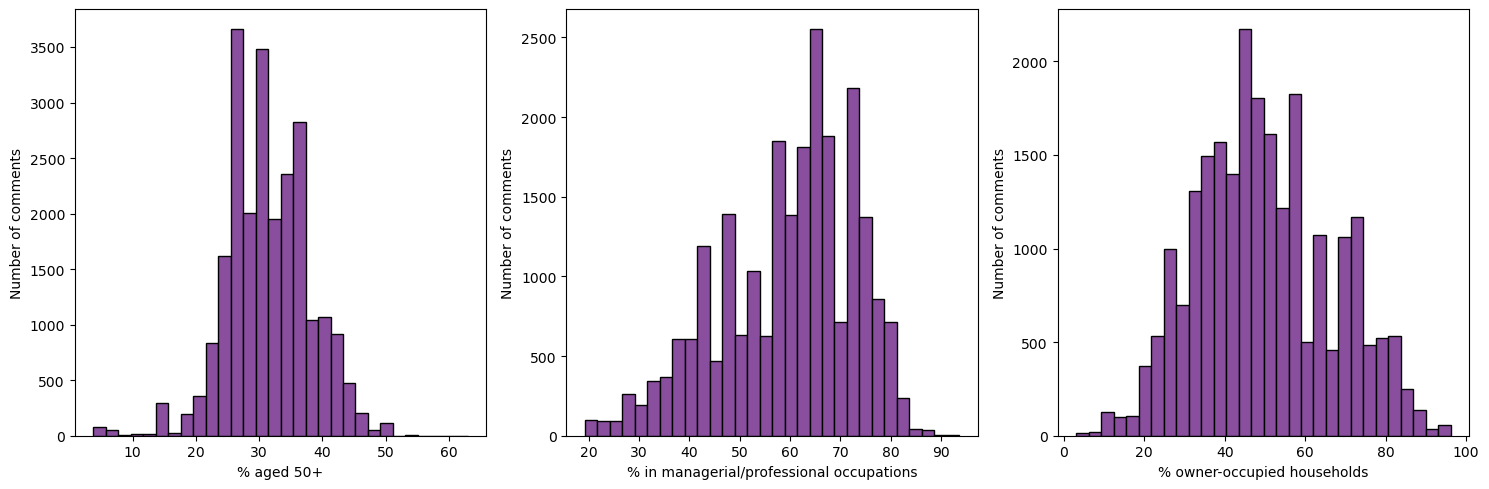

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, socio_vars):
    ax.hist(comment_df[var].dropna(), bins=30, color="#894e9e", edgecolor="black")
    ax.set_xlabel(x_labels[var])
    ax.set_ylabel("Number of comments")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demographic_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
